# **SPECTRA-CQ Phase 3: Synthetic Anomaly Detection (Single Sensor `PE11`)**

This notebook executes the final evaluation of the single-sensor Phase-3 (optimized HQAE) architecture.

This notebook evaluates the empirical resilience of our models using **Synthetic Anomaly Injection** $\leftarrow$ because dynamic high-frequency acceleration data for the 2025 physical load tests is unavailable in the OpenLAB dataset.

### **Objective**
To scientifically prove whether the extreme parameter efficiency of the quantum latent space acts as a geometric regularizer against overfitting.

We will inject mathematical structural degradation (Gaussian noise and frequency band masking) into unseen healthy spectrograms. We will evaluate three frozen architectures:
1. **Classical Baseline (CAE):** High parameter count. Susceptible to memorizing environmental noise.
2. **HQAE `none` (Depth 3):** The unentangled quantum champion from Phase 4a.
3. **HQAE `strong` (Depth 3):** The highly entangled quantum baseline.

**Evaluation Metric:** Area Under the Receiver Operating Characteristic Curve (AUC-ROC).

In [1]:
import os
import glob
import torch
import numpy as np
from google.colab import drive

# 1. Mount Data Drive
drive.mount('/content/drive')

# 2. Clone Github Repository
GITHUB_TOKEN = "PAT" # Scrubbed for security
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt -q

# Append path to allow module imports
import sys
sys.path.append('/content/SPECTRA-CQ')

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 280, done.
remote: Counting objects: 100% (207/207), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 280 (delta 82), reused 178 (delta 54), pack-reused 73 (from 1)
Receiving objects: 100% (280/280), 34.04 MiB | 33.87 MiB/s, done.
Resolving deltas: 100% (92/92), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/2

In [ ]:
# Import core modular logic
from src.models.classical.cae import ClassicalAutoencoder
from src.models.hybrid.hqae import HybridQuantumAutoencoder
from src.data.synthetic import prepare_evaluation_tensors
from src.engine.evaluator import AnomalyEvaluator
from src.utils.viz import plot_roc_curve

In [3]:
# Hardware Verification
# Since we are only doing inference (forward passes) not training (no gradient optimization or backpropogation)
# requires less compute power ⇒ GPU not necessarily required for execution
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Inference on: {device}")

Executing Inference on: cpu


### **Data Ingestion (I/O Optimized) + Synthetic Damage Generation**
We isolate 200 `float32` spectrograms from the 2024 healthy dataset to act as our completely unseen test set.

In [4]:
import os
import shutil

# Transfer the spectrograms from Drive to Colab's local NVMe
print("Transferring .zip PE11 sensor spectrograms dataset to local NVMe storage..")
# Add a check to skip unzip if already extracted (saves time if you re-run the cell)
if not os.path.exists('/content/local_spectra_data/processed_spectrograms'):
    !cp /content/drive/MyDrive/spectra-cq-data/spectra_matrices.zip /content/
    !unzip -q /content/spectra_matrices.zip -d /content/local_spectra_data/
    !rm /content/spectra_matrices.zip
    print("Data extraction complete.")
else:
    print("Data already extracted locally. Skipping unzip.")

# 2. Point DATA_DIR to the exact nested folder
DATA_DIR = "/content/local_spectra_data/processed_spectrograms"
print("Fetching file list...")

try:
    all_files = [entry.path for entry in os.scandir(DATA_DIR) if entry.name.endswith('.npy')]
except FileNotFoundError:
    print(f"Error: Could not find directory {DATA_DIR}.")
    all_files = []

# Isolate the last 200 unseen spectrograms
test_files = sorted(all_files)[-200:]

print(f"Generating incipient synthetic anomalies for {len(test_files)} samples...")

# Generate PyTorch tensors of shape (Batch, Channels, Height, Width)
t_healthy, t_damaged = prepare_evaluation_tensors(test_files)

print(f"Healthy Tensor Shape: {t_healthy.shape}")
print(f"Damaged Tensor Shape: {t_damaged.shape}")

Transferring .zip PE11 sensor spectrograms dataset to local NVMe storage..
Data extraction complete.
Fetching file list...
Generating incipient synthetic anomalies for 200 samples...
Healthy Tensor Shape: torch.Size([200, 1, 64, 1000])
Damaged Tensor Shape: torch.Size([200, 1, 64, 1000])


### **Multi-Seed Ensemble Inference**
To ensure our conclusions are statistically robust and not dependent on a lucky initialization $\rightarrow$ we will evaluate the architectures across all three deterministic seeds used in training (`42, 100, 2026`).

The engine computes the absolute reconstruction error (MSE) for each individual spectrogram, accumulates the scores across all seeds, and then averages them to create a highly reliable ensemble prediction.

In [5]:
SEEDS = [42, 100, 2026]
BASE_DIR = "/content/drive/MyDrive/spectra-cq-data/checkpoints"

# 1. Instantiate Models
cae_model = ClassicalAutoencoder(latent_dim=8)
hqae_none = HybridQuantumAutoencoder(latent_dim=8, n_quantum_layers=3, topology="none")
hqae_strong = HybridQuantumAutoencoder(latent_dim=8, n_quantum_layers=3, topology="strong")

# 2. Initialize Evaluator Engines
eval_cae = AnomalyEvaluator(cae_model, device)
eval_none = AnomalyEvaluator(hqae_none, device)
eval_strong = AnomalyEvaluator(hqae_strong, device)

# 3. Arrays to accumulate the MSE scores across all seeds
cae_h_accum, cae_d_accum = np.zeros(len(t_healthy)), np.zeros(len(t_damaged))
none_h_accum, none_d_accum = np.zeros(len(t_healthy)), np.zeros(len(t_damaged))
strong_h_accum, strong_d_accum = np.zeros(len(t_healthy)), np.zeros(len(t_damaged))

print("Executing Ensemble Inference across all seeds..")

for seed in SEEDS:
    print(f"\n → Loading and evaluating Seed {seed}")

    # Load Weights for this specific seed
    cae_model.load_state_dict(torch.load(f"{BASE_DIR}/classical/seed_{seed}/best_cae_model.pth", map_location=device))
    hqae_none.load_state_dict(torch.load(f"{BASE_DIR}/quantum/none_d3/seed_{seed}/best_model.pth", map_location=device))
    hqae_strong.load_state_dict(torch.load(f"{BASE_DIR}/quantum/strong_d3/seed_{seed}/best_model.pth", map_location=device))

    # Run Inference and Accumulate
    cae_h_accum += eval_cae.get_anomaly_scores(t_healthy)
    cae_d_accum += eval_cae.get_anomaly_scores(t_damaged)

    none_h_accum += eval_none.get_anomaly_scores(t_healthy)
    none_d_accum += eval_none.get_anomaly_scores(t_damaged)

    strong_h_accum += eval_strong.get_anomaly_scores(t_healthy)
    strong_d_accum += eval_strong.get_anomaly_scores(t_damaged)

# 4. Average the accumulated scores by the number of seeds
cae_scores = np.concatenate([cae_h_accum / len(SEEDS), cae_d_accum / len(SEEDS)])
none_scores = np.concatenate([none_h_accum / len(SEEDS), none_d_accum / len(SEEDS)])
strong_scores = np.concatenate([strong_h_accum / len(SEEDS), strong_d_accum / len(SEEDS)])

print("\nEnsemble Inference complete. Scores averaged.")

Executing Ensemble Inference across all seeds..

 → Loading and evaluating Seed 42

 → Loading and evaluating Seed 100

 → Loading and evaluating Seed 2026

Ensemble Inference complete. Scores averaged.


### **AUC-ROC Visualization**
We define the ground truth array as:
* $0$ for healthy
* $1$ for damaged

And map the True Positive Rate against the False Positive Rate across all internal decision thresholds.

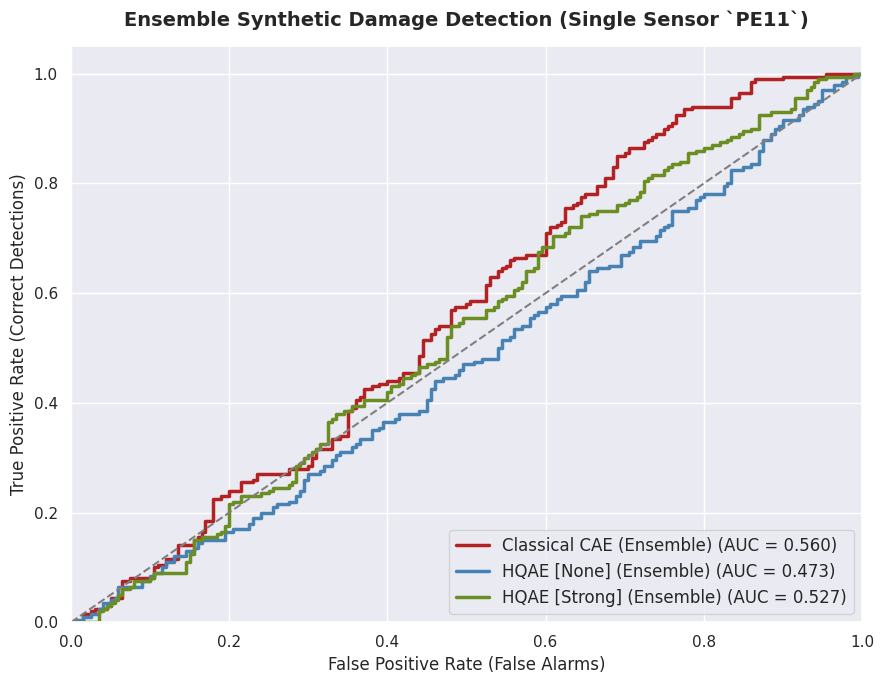

In [6]:
# Create Ground Truth Array (First half is Healthy, Second half is Damaged)
y_true = np.concatenate([np.zeros(len(t_healthy)), np.ones(len(t_damaged))])

# Map scores to their respective model names for the plotting function
results_dict = {
    "Classical CAE (Ensemble)": cae_scores,
    "HQAE [None] (Ensemble)": none_scores,
    "HQAE [Strong] (Ensemble)": strong_scores
}

# Generate the Comparative ROC Curve
plot_roc_curve(
    scores_dict=results_dict,
    y_true=y_true,
    title="Ensemble Synthetic Damage Detection (Single Sensor `PE11`)"
)

> NOTE :
> * AuC of `~1.000` is a massive red flag $\implies$ model detects damage too perfectly $\implies$ either data has leaked or the instance of damage is too big and easy to guess
> * AuC of `~0.500` $\implies$ a random guess
> * AuC `less than 0.500` $\implies$ performance is even worse than a 50-50nrandom guess
> * We aim for an ideal model with AuC `between 0.90 to 0.98`

### **Empirical Observations and Inference**

#### **1. The Incipient Damage Bottleneck**
* **Catastrophic Failure Testing:**
  * When subjected to massive, catastrophic synthetic damage (30% noise $\rightarrow$ simulates massive failure such as a bomb blast) $\rightarrow$ all architectures achieved an AUC of ~1.000
  * This indicates trivial detectability
* **Incipient Damage Testing:**
  * But, when we calibrated for real-world incipient damage (2% noise + narrow frequency masking $\rightarrow$ simulates early-stage micro-cracking) $\rightarrow$ the performance of all single-sensor models plummeted to random guessing (i.e., AUC ~0.500):
    * **Classical CAE:** ~0.560
    * **HQAE [Strong]:** ~0.527
    * **HQAE [None]:** ~0.473

#### **2. Interpretation of scores**
* **The Classical CAE (Memorization):**
  * Classical CAE has thousands of trainable weights (over-parameterized)
  * This over-parameterization has a tendency to memorize complex noise patterns.
  * It managed to slightly differentiate the 2% synthetic mathematical noise from the natural environmental baseline $\implies$ resulted in a marginal (but practically useless) bump above 0.500.
* **The HQAE [None] (Regularization):**
  * Hybrid HQAE has only only 24 parameters
  * Also, the unentangled topology acts as an extreme geometric regularizer
  * It aggressively smoothed out the 2% anomaly $\rightarrow$ treating it as standard environmental variance (such as a gust of wind).
  * It completely smoothed the damage away because a single sensor did not provide enough context to validate it as a structural failure.

#### **3. Limitation of a Single Sensor**
This empirical result proves a fundamental physical limitation of localized Structural Health Monitoring (SHM): a single accelerometer (PE11) simply lacks the necessary signal-to-noise ratio and spatial context to distinguish subtle, early-stage structural degradation from routine environmental variance.

The mathematical features of incipient damage are virtually indistinguishable from background noise when viewed through a single spatial node.

#### **4. Conclusion + Pivot to Multi-Sensor Fusion**
If a single sensor cannot reliably detect localized anomalies, the system must map the global correlations of the entire structure. A local micro-crack will alter the phase and vibration relationship between a sensor near the damage (e.g., Element 2.1) and a sensor located spans away (e.g., PE11).

Therefore, to achieve true early-warning anomaly detection $\rightarrow$ we must transition to a **Multi-Sensor Fusion** architecture (ingest PE11, PE12, PE13, PE21, PE22 and PE23 simultaneously).

This mathematically justifies the ultimate test of the Quantum Advantage: while classical networks struggle to map complex spatial correlations without exploding parameter counts, **Quantum Entanglement (`CNOT` gates)** is theoretically designed by physics to map highly correlated, multi-dimensional states efficiently.